# **3. XGBoost con TF-IDF**

El método **TF-IDF (Term Frequency–Inverse Document Frequency)** convierte cada documento en un vector numérico que pondera la relevancia de cada palabra en función de su frecuencia en el documento y su rareza en el corpus completo. Esto permite capturar la importancia léxica sin depender de un contexto secuencial, priorizando términos distintivos que caracterizan cada categoría.

Posteriormente, el algoritmo **XGBoost (Extreme Gradient Boosting)** utiliza esos vectores para entrenar un modelo de clasificación. 

In [1]:
# Librerias
import os, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,accuracy_score,confusion_matrix,
    precision_score,recall_score,f1_score
)
from xgboost import XGBClassifier


In [2]:
# MODULO DE MANEJO DE DATOS
# ---------------------------------

#  [Carga de datos]
df = pd.read_json('../Data/clean_words.json', lines=True)
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")

# Codificar etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

# Dividir dataset
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
train, val, test = train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

print(f"Distribución de los datos: \nTrain: {len(train)} | Val: {len(val)} | Test: {len(test)}")


y_train, y_val, y_test = train['label'], val['label'], test['label']

num_classes = len(le.classes_)
print(f"Número de clases: {num_classes}")

Registros totales: 2483
Distribución de los datos: 
Train: 1738 | Val: 372 | Test: 373
Número de clases: 5


## 🔹Modelo

In [3]:
# MODULO DATASET
# -------------------------
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(train['clean_text'])
X_val_tfidf   = tfidf.transform(val['clean_text'])
X_test_tfidf  = tfidf.transform(test['clean_text'])


In [4]:
# MODULO MODELO
# -------------------------

# Configuración de hiperparámetros
params = {
    "objective": "multi:softprob",
    "num_class": num_classes,
    "n_estimators": 100,       # más árboles, pero cada uno aprende más lento
    "max_depth": 4,            # menos profundidad = menos sobreajuste
    "learning_rate": 0.05,     # pasos más pequeños
    "subsample": 0.8,          # usa el 80% de muestras por árbol (mejor generalización)
    "colsample_bytree": 0.8,   # usa el 80% de features
    "reg_lambda": 1.0,         # L2 regularización
    "reg_alpha": 0.5,          # L1 regularización (sparse)
    "min_child_weight": 3,     # evita que árboles crezcan con pocos ejemplos
    "tree_method": "hist",
    "eval_metric": "mlogloss",
    "random_state": SEED,
}

base_dir = "results/XGBoost_TFIDF"
os.makedirs(base_dir, exist_ok=True)

xgb = XGBClassifier(**params)

# Entrenamiento del modelo
time_start = time.time()
xgb.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_train_tfidf, y_train), (X_val_tfidf, y_val)],
    verbose=True,
)
print("\n🔹Tiempo de entrenamiento: %.2f minutos" % ((time.time() - time_start) / 60))


# Guardar modelo y vectorizador
joblib.dump(xgb, os.path.join(base_dir, "xgb_model.joblib"))
joblib.dump(tfidf, os.path.join(base_dir, "tfidf_vectorizer.joblib"))

[0]	validation_0-mlogloss:1.54583	validation_1-mlogloss:1.54882


[1]	validation_0-mlogloss:1.49335	validation_1-mlogloss:1.49785


[2]	validation_0-mlogloss:1.44849	validation_1-mlogloss:1.45643


[3]	validation_0-mlogloss:1.40192	validation_1-mlogloss:1.41491


[4]	validation_0-mlogloss:1.35592	validation_1-mlogloss:1.37248


[5]	validation_0-mlogloss:1.31402	validation_1-mlogloss:1.33376


[6]	validation_0-mlogloss:1.27608	validation_1-mlogloss:1.29847


[7]	validation_0-mlogloss:1.24203	validation_1-mlogloss:1.26868


[8]	validation_0-mlogloss:1.20783	validation_1-mlogloss:1.23787


El modelo XGBoost, se muestra la evolución de la función de pérdida (loss) en cada iteración. Tanto para el conjunto de entrenamiento y validación se reduce constantemente, evidenciando que el modelo aprende de manera progresiva y generaliza bien. No existe una divergencia o sobreajuste evidente.

## 🔹 Evaluación de rendimiento

EVALUACION DEL MODELO

=== HIPERPARAMETROS DEL MODELO ===
objective: multi:softprob
num_class: 5
n_estimators: 100
max_depth: 4
learning_rate: 0.05
subsample: 0.8
colsample_bytree: 0.8
reg_lambda: 1.0
reg_alpha: 0.5
min_child_weight: 3
tree_method: hist
eval_metric: mlogloss
random_state: 42

=== MÉTRICAS EN VALIDACIÓN ===
Accuracy: 0.8199 | F1-macro: 0.8191

=== MÉTRICAS EN TEST ===
Accuracy: 0.8123 | F1-macro: 0.8115

=== CLASSIFICATION REPORT (TEST) ===
                                    precision    recall  f1-score   support

          Creatividad y Producción       0.87      0.76      0.81        63
               Negocios y Finanzas       0.85      0.78      0.82        88
            Otros y Especializados       0.83      0.70      0.76        71
Servicios Profesionales y Públicos       0.75      0.87      0.81        84
              Tecnología y Ciencia       0.79      0.94      0.86        67

                          accuracy                           0.81       373
     

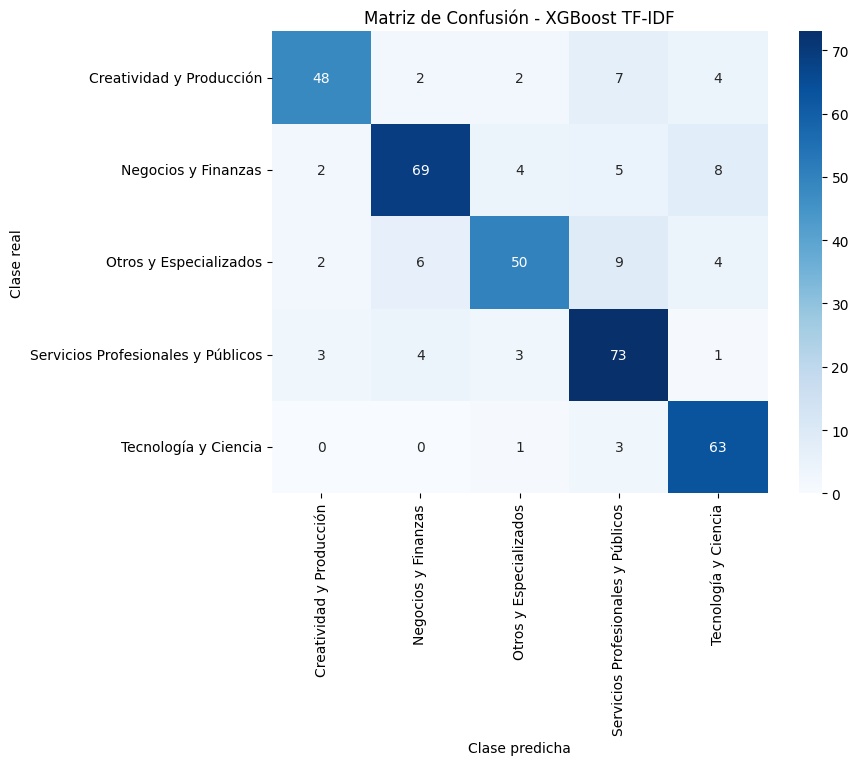

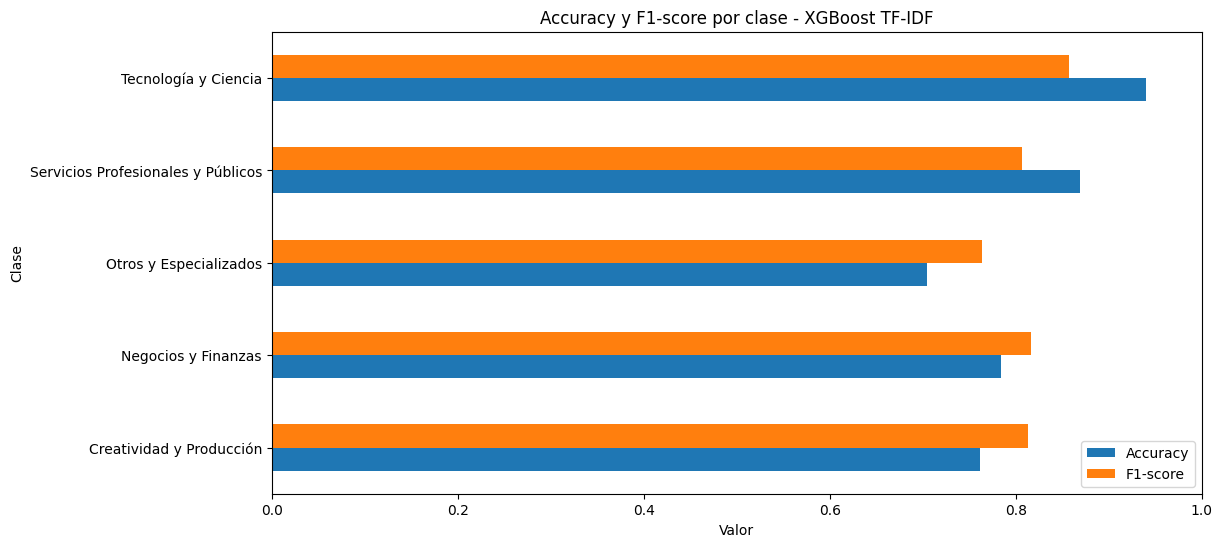

In [9]:
# -------------------------
# EVALUACIÓN DEL MODELO XGBOOST TF-IDF
# -------------------------

print("EVALUACION DEL MODELO")

# ---- Hiperparámetros ----
print("\n=== HIPERPARAMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

# ---- Predicciones en Validación (opcional si tienes X_val_tfidf, y_val) ----
val_available = 'X_val_tfidf' in locals() and 'y_val' in locals()
if val_available:
    val_preds = xgb.predict(X_val_tfidf)
    val_acc = accuracy_score(y_val, val_preds)
    val_f1 = f1_score(y_val, val_preds, average='macro')
    print("\n=== MÉTRICAS EN VALIDACIÓN ===")
    print(f"Accuracy: {val_acc:.4f} | F1-macro: {val_f1:.4f}")

# ---- Evaluación en Test ----
test_preds = xgb.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds, average='macro')

print("\n=== MÉTRICAS EN TEST ===")
print(f"Accuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# ---- Classification report ----
target_names = le.classes_
report = classification_report(y_test, test_preds, target_names=target_names, output_dict=True, zero_division=0)
print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, test_preds, target_names=target_names, zero_division=0))

# ---- Matriz de confusión ----
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión - XGBoost TF-IDF")
plt.show()

# ---- Gráfico de métricas por clase (Acc y F1) ----
per_class_f1 = [report[label]['f1-score'] for label in target_names]
per_class_acc = [np.mean(test_preds[y_test == i] == i) for i, _ in enumerate(target_names)]

metrics_plot_df = pd.DataFrame({
    "Clase": target_names,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})

metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='barh', figsize=(12,6))
plt.title("Accuracy y F1-score por clase - XGBoost TF-IDF")
plt.xlabel("Valor")
plt.xlim(0, 1)
plt.yticks(rotation=0)
plt.show()


La evaluación del modelo, arroja que el rendimiento en el conjunto de validación (ACC = 0.8199, F1 = 0.8191) frente al de test (ACC = 0.8123, F1 = 0.8115) es muy reducida, indicando que el modelo generaliza muy bien y de manera acertada.

En general, todas las clases tienen un F1 mayor a 0.75, lo que demuestra alta la capacidad de generalización del modelo. Para los grupos de _Tecnología y Ciencia_ y _Servicios profesionales y publicos_ el Accuracy es el más alto, reflejado en una menor de cantidad de casos erroneamente clasificados.

Las métricas evidencian la facilidad del modelo para realizar clasificación de textos en hojas de vida, estando regularizado, sin sobreajuste y con un desempeño balanceado entre clases.